# Chicago Crime Era Analysis
## Does COVID-19 correlate with changes in Chicago crime patterns?

**Author:** Erik Pak<br>
**Date:** 04/2026<br>
**Data:** Chicago Data Portal - Crime Incidents 2001–2025

---

## Research Question
Did the frequency and distribution of crime types in Chicago change significantly across three eras: Pre-COVID, COVID, and Post-COVID?

## Era Definitions

| Era        | Period                  | Months |
|------------|-------------------------|--------|
| Pre-COVID  | Jan 2001 – Feb 2020     | 230    |
| COVID      | Mar 2020 – Dec 2022     | 34     |
| Post-COVID | Jan 2023 – Dec 2025     | 36     |

Era cutoff rationale: The COVID era begins in March 2020, coinciding with the Illinois stay-at-home order (March 21, 2020) and the WHO pandemic declaration (March 11, 2020). The post-COVID era begins in January 2023, following the expiration of Illinois's disaster proclamation and the effective end of major federal pandemic-era policies in late 2022. These boundaries are administrative and policy-based; the underlying behavioral and enforcement shifts may not align exactly with these dates.

---

## Abstract
This analysis examines 8.4 million Chicago crime incidents (2001–2025) across three eras: Pre-COVID, COVID, and Post-COVID to determine whether the pandemic produced measurable, lasting shifts in crime patterns. Using Kruskal-Wallis tests with Benjamini-Hochberg FDR correction across 26 crime types, 24 showed statistically significant differences. The pandemic produced two durable level shifts: a collapse in opportunity-driven crimes (gambling −97.8%, prostitution −93.5%, drug abuse −83.6%) and an acceleration of violence-related offenses (weapons violations +81.2%, motor vehicle theft +32.8%). Dunn's post-hoc testing indicates 17 of 24 affected crimes have stabilized into a new post-COVID baseline, suggesting these shifts are durable rather than transitional. Homicide is the sole violent crime to return to pre-COVID levels.

**Data window:** This analysis uses Chicago crime data from January 2001 through December 2025 (300 months, 36 months of post-COVID observation). The companion notebook `ChicagoCrimeDetection.ipynb` uses a slightly extended snapshot through April 2026 (304 months); the shorter window here does not affect the substantive findings, and both extracts produce the same trajectory classifications.

**Category coverage note:** This notebook tests 26 crime categories (including Involuntary Manslaughter / Reckless Homicide, which the test correctly rejects at p=0.505 as not showing era-related differences). The companion notebook `ChicagoCrimeDetection.ipynb` excludes Involuntary Manslaughter pre-analysis because its 23.4% monthly coverage is too sparse for compositional modeling. Including it in this count-based test is methodologically appropriate; the test correctly rejects it.

## Companion Notebook

`ChicagoCrimeDetection.ipynb` analyzes the same Chicago crime data using the centered log-ratio (CLR) transformation and multivariate methods (PCA, multivariate changepoint detection via Dynp and Pelt, and the Frobenius distance between per-era correlation matrices). The two analyses are complementary: this notebook documents that **individual category levels** shifted significantly between eras (24 of 26 categories, with durable post-COVID baselines for 17 of them); the companion notebook finds that, despite these level shifts, the **multivariate compositional structure** of crime, how categories co-move with each other, evolved gradually rather than breaking discretely at the pandemic. Together they show that *what crimes are reported* shifted measurably, while *how crime categories relate to one another* did not undergo a discrete break.

In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.feather as feather
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# python source path
sys.path.append('../Src/')
# Set seed
SEED = 1776

# custom python
import chicago_crime_utilities as utils
import chicago_mapping_code as mapping_code
import chicago_crime_kruskal_fdr as kruskal_fdr
import chicago_crime_dunn_posthoc as dunn_posthoc

# Create a dictionary of versions
versions = {
    "Python"  : sys.version.split()[0],
    "Pandas"  : pd.__version__,
    "Pyarrow" : pa.__version__,
    "NumPy"   : np.__version__,
    "Seaborn" : sns.__version__,
    "Matplot" : sys.modules['matplotlib'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# Remove scientific notation
np.set_printoptions(suppress=True, precision=4, linewidth=100)
# reset options
pd.set_option('display.max_rows', None)

# Use a single Arrow string & int64 type instance to save memory
arrow_string = pd.ArrowDtype(pa.string())
arrow_cat8 = pd.ArrowDtype(pa.dictionary(index_type=pa.int8(), value_type=pa.string()))

   Library Version
0   Python  3.13.9
1   Pandas   2.3.3
2  Pyarrow  22.0.0
3    NumPy   2.3.4
4  Seaborn  0.13.2
5  Matplot  3.10.7


## Data Import
Chicago crime incident data loaded from a PyArrow Feather file for memory-efficient columnar access. The dataset contains 8,469,443 records across 33 columns spanning January 2001 through December 2025.

In [2]:
# PyArrow's version of the 'arrow' backend
df = feather.read_feather('../Data/crime_data.feather', memory_map=True, types_mapper=pd.ArrowDtype)
# display
df.head()

,case_number,date,block,iucr,primary_description,secondary_description,index_code,primary_type,description,location_description,...,y_coordinate,era,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location
8265318,01G050460,2001-01-24 20:45:00,072XX S RIDGELAND AV,1811,NARCOTICS,POSSESS - CANNABIS 30 GRAMS OR LESS,N,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,...,1857566,pre_covid,January,Wednesday,Q1,2001-Q1,Night,Drug Abuse Violations,False,Grand Crossing
7080787,03J493690,2003-07-12 17:00:00,075XX S DOBSON AVE,0890,THEFT,FROM BUILDING,I,THEFT,FROM BUILDING,APARTMENT,...,1854276,pre_covid,July,Saturday,Q3,2003-Q3,Evening,Larceny - Theft,True,Gresham
6396203,04X245238,2004-12-13 21:15:00,006XX N RIDGEWAY AVE,2024,NARCOTICS,POSSESS - HEROIN (WHITE),N,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,...,1903996,pre_covid,December,Monday,Q4,2004-Q4,Night,Drug Abuse Violations,False,Harrison
5818733,07C115980,2006-03-31 09:15:00,026XX N NARRAGANSETT AVE,0610,BURGLARY,FORCIBLE ENTRY,I,BURGLARY,FORCIBLE ENTRY,APARTMENT,...,1916864,pre_covid,March,Friday,Q1,2006-Q1,Morning,Burglary,True,Grand Central
5312174,07HN36467,2007-05-25 14:51:00,022XX N LA CROSSE AVE,1812,NARCOTICS,POSSESS - CANNABIS MORE THAN 30 GRAMS,N,NARCOTICS,POSS: CANNABIS MORE THAN 30GMS,RESIDENCE,...,1914371,pre_covid,May,Friday,Q2,2007-Q2,Afternoon,Drug Abuse Violations,False,Grand Central


In [3]:
# Check for NaNs
utils.any_nans(df)

--- Missing Values Found (Total Rows: 8,543,089) ---
                       Count Percentage
primary_description    19371    0.2267%
secondary_description  19371    0.2267%
index_code             19371    0.2267%
location_description   15968    0.1869%


## Add Year-Week Number
ISO 8601 week number (`%G-%V`) added as `year_week` to support weekly aggregation. ISO format is used rather than `%Y-%W` to correctly handle week boundaries at year-end.

In [4]:
# year & Week Number
df["year_week"] = df["date"].dt.strftime("%G-%V")
# Convert datatype
df["year_week"] = df["year_week"].astype(arrow_string)
# display
df[['date', 'year_week']].head()

,date,year_week
8265318,2001-01-24 20:45:00,2001-04
7080787,2003-07-12 17:00:00,2003-28
6396203,2004-12-13 21:15:00,2004-51
5818733,2006-03-31 09:15:00,2006-13
5312174,2007-05-25 14:51:00,2007-21


#### Yearly

In [5]:
# remove 2026: not complete
max_year =  df['date'].dt.year.max()
df = df.loc[df['date'].dt.year < max_year].copy()
#
min_year =  df['date'].dt.year.min()
max_year =  df['date'].dt.year.max()

## Add Year-Month Number
`year_month` added in `YYYYMM` format to support monthly aggregation, the primary unit of analysis for era comparisons.

In [6]:
# Create the new column using .dt.strftime (Unit of Analysis: Year & Month)
df['year_month'] = df['date'].dt.strftime('%Y%m')

# convert year_month to int
df.year_month = df.year_month.astype(arrow_string)
# check the datatype
print(df.year_month.dtype)
# display
df[['date','year_month']].head()

string[pyarrow]


,date,year_month
8265318,2001-01-24 20:45:00,200101
7080787,2003-07-12 17:00:00,200307
6396203,2004-12-13 21:15:00,200412
5818733,2006-03-31 09:15:00,200603
5312174,2007-05-25 14:51:00,200705


In [7]:
# display
df.sample(n=5, random_state=SEED)

,case_number,date,block,iucr,primary_description,secondary_description,index_code,primary_type,description,location_description,...,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location,year_week,year_month
1822970,JA478296,2017-10-19 12:45:00,082XX S CALUMET AVE,0610,BURGLARY,FORCIBLE ENTRY,I,BURGLARY,FORCIBLE ENTRY,RESIDENCE,...,October,Thursday,Q4,2017-Q4,Afternoon,Burglary,True,Gresham,2017-42,201710
6598118,HK488990,2004-07-11 17:40:00,009XX W MONTROSE AVE,0890,THEFT,FROM BUILDING,I,THEFT,FROM BUILDING,OTHER,...,July,Sunday,Q3,2004-Q3,Evening,Larceny - Theft,True,Town Hall,2004-28,200407
777762,JF254214,2022-03-18 20:30:00,052XX S BLACKSTONE AVE,0810,THEFT,OVER $500,I,THEFT,OVER $500,APARTMENT,...,March,Friday,Q1,2022-Q1,Night,Larceny - Theft,True,Wentworth,2022-11,202203
202305,JH297932,2024-06-08 04:50:00,022XX S PULASKI RD,0820,THEFT,$500 AND UNDER,I,THEFT,$500 AND UNDER,OTHER (SPECIFY),...,June,Saturday,Q2,2024-Q2,Early Morning,Larceny - Theft,True,Ogden,2024-23,202406
4475076,HR317431,2009-05-12 12:00:00,079XX S WABASH AVE,0610,BURGLARY,FORCIBLE ENTRY,I,BURGLARY,FORCIBLE ENTRY,APARTMENT,...,May,Tuesday,Q2,2009-Q2,Afternoon,Burglary,True,Gresham,2009-20,200905


In [8]:
# display number of unique values
for i in df.columns:
    print(f"{i}: {df[i].nunique():,}")

case_number: 8,476,442
date: 3,548,254
block: 65,550
iucr: 418
primary_description: 32
secondary_description: 369
index_code: 2
primary_type: 34
description: 569
location_description: 183
arrest: 2
domestic: 2
beat: 305
district: 22
ward: 50
community_code: 77
year: 25
updated_on: 7,657
fbi_code: 26
zip_code: 59
zip_code_area: 59
primary_neighborhood: 98
secondary_neighborhood: 78
neighborhood_area: 98
sector: 5
ca_community_code: 77
ca_community_name: 77
ca_community_area: 77
latitude: 909,835
longitude: 909,232
x_coordinate: 79,358
y_coordinate: 130,439
era: 3
month: 12
day_of_week: 7
quarter: 4
year_quarter: 100
time_of_day: 6
fbi_code_desc: 26
fbi_index_code: 2
district_location: 22
year_week: 1,305
year_month: 300


In [9]:
print(df.era.unique())

<ArrowExtensionArray>
['pre_covid', 'post_covid', 'covid']
Length: 3, dtype: dictionary<values=string, indices=int8, ordered=0>[pyarrow]


In [10]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 8476442 entries, 8265318 to 5025838
Data columns (total 43 columns):
 #   Column                  Non-Null Count    Dtype                                                      
---  ------                  --------------    -----                                                      
 0   case_number             8476442 non-null  string[pyarrow]                                            
 1   date                    8476442 non-null  timestamp[s][pyarrow]                                      
 2   block                   8476442 non-null  string[pyarrow]                                            
 3   iucr                    8476442 non-null  string[pyarrow]                                            
 4   primary_description     8461185 non-null  string[pyarrow]                                            
 5   secondary_description   8461185 non-null  string[pyarrow]                                            
 6   index_code              8

## Category

In [11]:
# Create New Columns: map: runs vectorized, column‑level operations.
df['Indexed'] = (
    df['fbi_index_code']
        .map({True: 'I', False: 'N'})
        .astype(arrow_cat8)
)

# Column List 
cols = ['fbi_code_desc', 'month', 'day_of_week', 'time_of_day', 'quarter', 'era']
# Convert columns to Arrow dictionary (unordered)
for col in cols:
    df[col] = df[col].astype(arrow_cat8)

In [12]:
df.head()

,case_number,date,block,iucr,primary_description,secondary_description,index_code,primary_type,description,location_description,...,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location,year_week,year_month,Indexed
8265318,01G050460,2001-01-24 20:45:00,072XX S RIDGELAND AV,1811,NARCOTICS,POSSESS - CANNABIS 30 GRAMS OR LESS,N,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,...,Wednesday,Q1,2001-Q1,Night,Drug Abuse Violations,False,Grand Crossing,2001-04,200101,N
7080787,03J493690,2003-07-12 17:00:00,075XX S DOBSON AVE,0890,THEFT,FROM BUILDING,I,THEFT,FROM BUILDING,APARTMENT,...,Saturday,Q3,2003-Q3,Evening,Larceny - Theft,True,Gresham,2003-28,200307,I
6396203,04X245238,2004-12-13 21:15:00,006XX N RIDGEWAY AVE,2024,NARCOTICS,POSSESS - HEROIN (WHITE),N,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,...,Monday,Q4,2004-Q4,Night,Drug Abuse Violations,False,Harrison,2004-51,200412,N
5818733,07C115980,2006-03-31 09:15:00,026XX N NARRAGANSETT AVE,0610,BURGLARY,FORCIBLE ENTRY,I,BURGLARY,FORCIBLE ENTRY,APARTMENT,...,Friday,Q1,2006-Q1,Morning,Burglary,True,Grand Central,2006-13,200603,I
5312174,07HN36467,2007-05-25 14:51:00,022XX N LA CROSSE AVE,1812,NARCOTICS,POSSESS - CANNABIS MORE THAN 30 GRAMS,N,NARCOTICS,POSS: CANNABIS MORE THAN 30GMS,RESIDENCE,...,Friday,Q2,2007-Q2,Afternoon,Drug Abuse Violations,False,Grand Central,2007-21,200705,N


## MultiIndex GroupBy
A 9-level groupby aggregates records by `fbi_code_desc`, `quarter`, `month`, `day_of_week`, `time_of_day`, `Indexed`, `year_week`, `year_month`, and `era`. This single aggregation step supports all downstream analyses without re-reading the raw data.

In [13]:
# Group and count
multi_counts = (df.groupby(['fbi_code_desc', 'quarter', 'month', 'day_of_week', 
                            'time_of_day', 'Indexed', 'year_week', 'year_month','era']).size())
multi_counts.isna().any()

np.False_

In [14]:
# Index names
multi_counts.index.names

FrozenList(['fbi_code_desc', 'quarter', 'month', 'day_of_week', 'time_of_day', 'Indexed', 'year_week', 'year_month', 'era'])

In [15]:
# Distinct Crime Type Values
print(list(multi_counts.index.get_level_values('fbi_code_desc').unique()))

['Aggravated Assault', 'Aggravated Battery', 'Arson', 'Burglary', 'Criminal Sexual Assault', 'Disorderly Conduct', 'Drug Abuse Violations', 'Embezzlement', 'Forgery and Counterfeiting', 'Fraud', 'Gambling', 'Homicide - 1st or 2nd Degree', 'Involuntary Manslaughter / Reckless Homicide', 'Larceny - Theft', 'Liquor Laws', 'Miscellaneous Non-Index Offenses', 'Motor Vehicle Theft', 'Offenses Against Family and Children', 'Prostitution', 'Robbery', 'Sex Offense - Criminal Sexual Abuse', 'Simple Assault', 'Simple Battery', 'Stolen Property (Buy, Receive, Possess)', 'Vandalism', 'Weapons Violations']


In [16]:
# display
multi_counts.head()

fbi_code_desc       quarter  month     day_of_week  time_of_day  Indexed  year_week  year_month  era      
Aggravated Assault  Q1       February  Friday       Afternoon    I        2001-05    200102      pre_covid    3
                                                                          2001-06    200102      pre_covid    3
                                                                          2001-07    200102      pre_covid    6
                                                                          2001-08    200102      pre_covid    5
                                                                          2002-05    200202      pre_covid    1
dtype: int64

## Monthly Average Comparison
Crime counts are normalized to crimes per month to account for unequal era lengths (230 months pre-COVID, 34 months COVID, and 36 months post-COVID). Raw counts are not comparable across eras without this adjustment.

In [17]:
# Converts MultiIndex to regular columns
multi_counts_df = multi_counts.reset_index(name='count')
multi_counts_df.head()

,fbi_code_desc,quarter,month,day_of_week,time_of_day,Indexed,year_week,year_month,era,count
0,Aggravated Assault,Q1,February,Friday,Afternoon,I,2001-05,200102,pre_covid,3
1,Aggravated Assault,Q1,February,Friday,Afternoon,I,2001-06,200102,pre_covid,3
2,Aggravated Assault,Q1,February,Friday,Afternoon,I,2001-07,200102,pre_covid,6
3,Aggravated Assault,Q1,February,Friday,Afternoon,I,2001-08,200102,pre_covid,5
4,Aggravated Assault,Q1,February,Friday,Afternoon,I,2002-05,200202,pre_covid,1


## Percentage of Crime by Era
Distribution of crime types as a share of total monthly crimes per era. Highlights durable level shifts in the composition of crime, not just absolute counts.

In [18]:
print('Pre-Covid:  ', multi_counts_df['year_month'][multi_counts_df.era == 'pre_covid'].nunique())
print('Covid:      ', multi_counts_df['year_month'][multi_counts_df.era == 'covid'].nunique())
print('Post-Covid: ',multi_counts_df['year_month'][multi_counts_df.era == 'post_covid'].nunique())

Pre-Covid:   230
Covid:       34
Post-Covid:  36


In [19]:
date_ranges = df.groupby('era')['date'].agg(['min', 'max'])
assert date_ranges.loc['pre_covid', 'max'].year == 2020
assert date_ranges.loc['covid', 'min'].year == 2020
assert date_ranges.loc['post_covid', 'min'].year == 2023
print(date_ranges)

                            min                  max
era                                                 
covid       2020-03-01 00:00:00  2022-12-31 23:55:00
post_covid  2023-01-01 00:00:00  2025-12-31 23:58:00
pre_covid   2001-01-01 00:00:00  2020-02-29 23:59:00


## Statistical Testing: Kruskal-Wallis + Benjamini-Hochberg FDR

**Question:** Are differences in monthly crime counts across eras 
statistically significant or attributable to chance?

**Method:** Kruskal-Wallis (non-parametric) chosen because:
* Crime counts are not normally distributed
* Sample sizes are severely unequal (230 vs 34 vs 36 months)
* No assumption of homogeneity of variance required

**Multiple Testing Problem:**
Running 26 simultaneous hypothesis tests at $\alpha = 0.05$ yields a 73.6% probability of at least one false positive:

$P(\text{at least one false positive}) = 1 - (1-0.05)^{26} = 0.736$

**Correction:** Benjamini-Hochberg False Discovery Rate (FDR) applied across all 26 crime types, controlling the expected proportion of false positives at 5%.

In [20]:
# Monthly analysis
monthly_results = kruskal_fdr.run_kruskal_fdr(
    data       = multi_counts_df,
    time_col = 'year_month',
    alpha    = 0.05
)
monthly_results

,crime,statistic,p_value,n,epsilon_squared,p_corrected,significant,effect_size
0,Aggravated Assault,40.48,0.000000,300,0.130,0.000000,True,medium
1,"Stolen Property (Buy, Receive, Possess)",48.57,0.000000,298,0.158,0.000000,True,large
2,Simple Battery,134.80,0.000000,300,0.447,0.000000,True,large
3,Simple Assault,57.33,0.000000,300,0.186,0.000000,True,large
4,Robbery,96.68,0.000000,300,0.319,0.000000,True,large
5,Prostitution,146.98,0.000000,298,0.491,0.000000,True,large
6,Offenses Against Family and Children,83.49,0.000000,300,0.274,0.000000,True,large
7,Motor Vehicle Theft,32.24,0.000000,300,0.102,0.000000,True,medium
8,Miscellaneous Non-Index Offenses,141.54,0.000000,300,0.470,0.000000,True,large
9,Liquor Laws,106.76,0.000000,300,0.353,0.000000,True,large


## Findings: Statistical Significance
24 of 26 crime types showed statistically significant differences across eras after Benjamini-Hochberg correction ($\alpha = 0.05$).

| Result           | Crimes |
|------------------|--------|
| Significant (24) | Weapons Violations, Drug Abuse Violations, Prostitution, Burglary, Gambling... |
| Not Significant (2) | Criminal Sexual Assault (p=0.052), Involuntary Manslaughter (p=0.505) |

**Note on non-significant results:**
These two crimes are meaningfully different in kind:
* **Criminal Sexual Assault (p=0.052):** borderline just above threshold, likely underpowered given the short COVID and post-COVID windows. Cannot rule out a real effect.
* **Involuntary Manslaughter (p=0.505):** no detectable pattern change across eras. Genuinely stable. (The companion notebook ChicagoCrimeDetection.ipynb excludes this category pre-analysis on compositional-modeling grounds because its 23.4% monthly coverage is too sparse for centered log-ratio transformation. Including it here, in a count-based test, is methodologically appropriate; the test correctly rejects it as non-significant.)

**Note on small effect sizes:**
Aggravated Battery, Arson, and Sex Offense show statistically significant differences but small effect sizes ($\epsilon^2 < 0.05$), likely reflecting the test's sensitivity to the large pre-COVID sample rather than meaningful distributional shifts. These three crimes are excluded from the substantive findings narrative; all conclusions below focus on crimes with medium or large effect sizes.

## Statistical Note - Unequal Group Sizes

> The three eras differ substantially in length: pre-COVID spans 230 months, COVID spans 34 months, and post-COVID spans 36 months. Kruskal-Wallis is robust to unequal group sizes and makes no normality assumption, so the test remains valid.
> However, the smaller COVID and post-COVID samples have lower statistical power, meaning real differences in those eras are slightly harder to detect. Results flagged as non-significant for 
> COVID-era crimes should be interpreted with this caveat in mind, not treated as evidence of no effect.
> **Temporal autocorrelation caveat:** Monthly crime counts in adjacent periods are not fully independent. Kruskal-Wallis assumes independence of observations. This does not invalidate the results but means p-values may be slightly optimistic. Findings are treated as exploratory rather than confirmatory.

## Normalization: Crimes Per Month

Raw crime counts cannot be compared directly across eras. Pre-COVID spans 230 months vs 34 (COVID) and 36 (Post-COVID). All comparisons use **crimes per month** to account for unequal era lengths. Era month counts are derived dynamically from the data, not hardcoded.

In [21]:
# Total incidents per crime + era
totals = (
    multi_counts_df
    .groupby(['fbi_code_desc', 'era'])
    .agg(crime_count=('count', 'sum'))
)

# Number of months per era: derive dynamically
era_months = (
    df.groupby('era')['year_month']
    .nunique()
    .to_dict()
)
# Normalize
totals['era_months']        = [era_months[str(e)] for e in totals.index.get_level_values('era')]
totals['crimes_per_month']  = totals['crime_count'] / totals['era_months']

# display
totals.head()

crime_count  era_months  crimes_per_month
fbi_code_desc      era                                                  
Aggravated Assault covid             19962          34        587.117647
                   post_covid        22199          36        616.638889
                   pre_covid        114801         230        499.134783
Aggravated Battery covid             23127          34        680.205882
                   post_covid        23375          36        649.305556

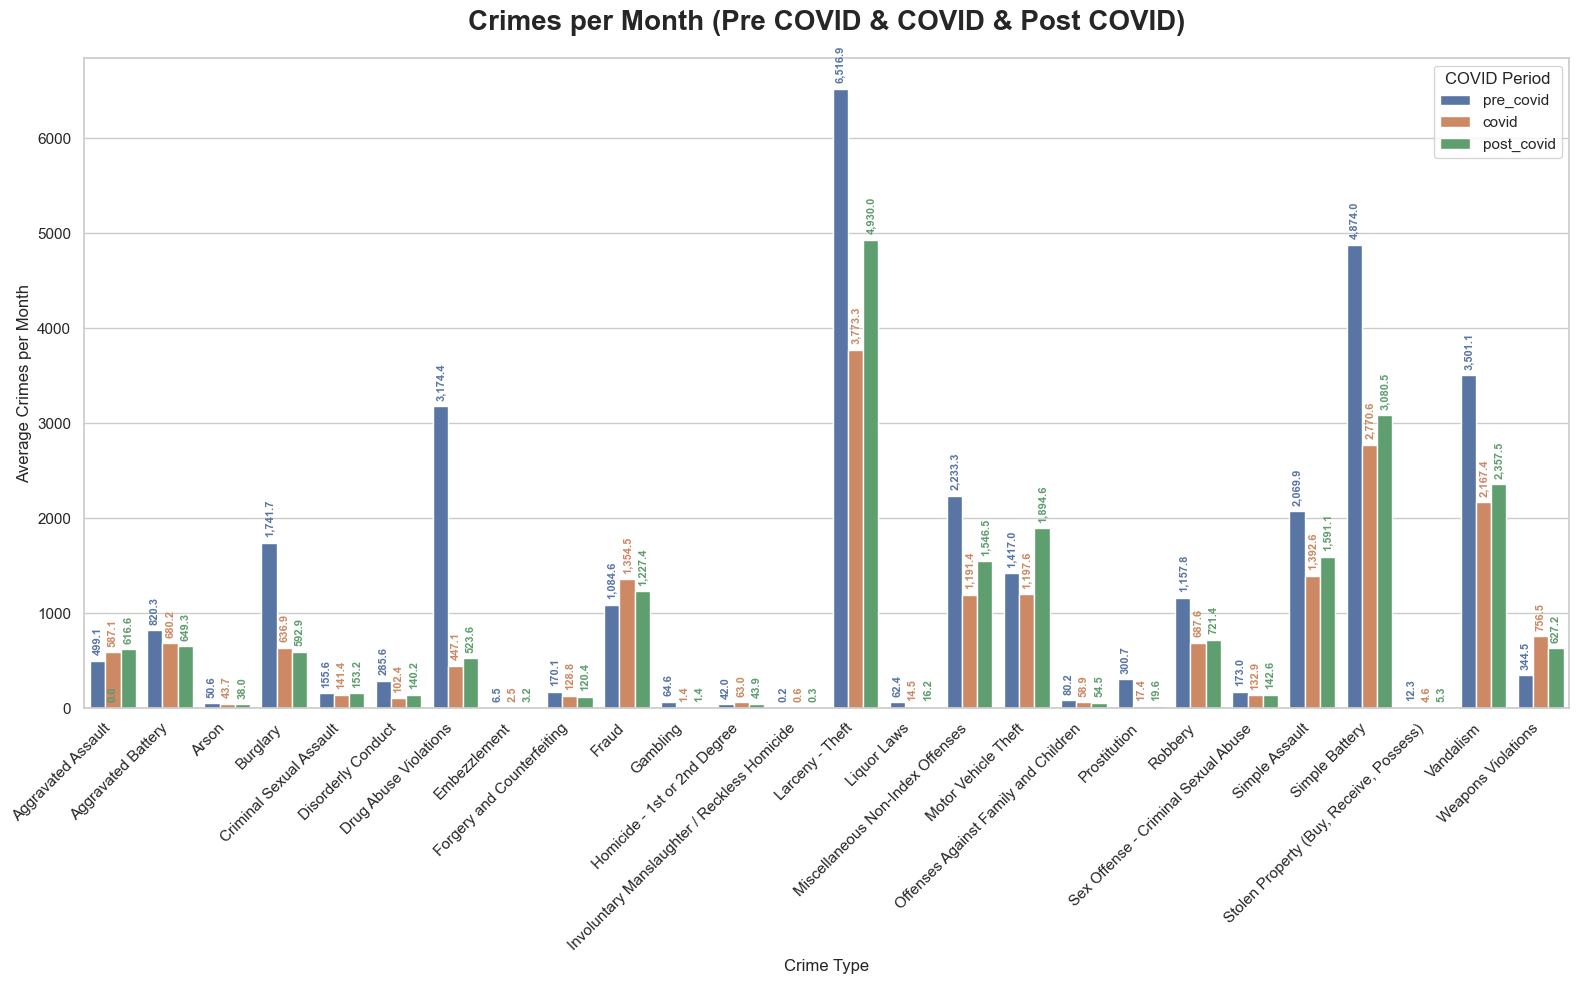

In [22]:
# Convert Arrow dictionary columns to plain Python strings 
df_plot = totals.reset_index()
df_plot["fbi_code_desc"] = df_plot["fbi_code_desc"].astype(str) 

# Enforce order
covid_order = ["pre_covid", "covid", "post_covid"]
df_plot["era"] = pd.Categorical(
    df_plot["era"],
    categories=covid_order,
    ordered=True
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))
ax = sns.barplot(
    data=df_plot,
    y="crimes_per_month",
    x="fbi_code_desc",
    hue="era"
)

for p in ax.patches:
    height = p.get_height()
    color = p.get_facecolor()   # get the bar's actual color

    ax.annotate(
        f"{height:,.1f}",                      # crimes per month, 1 decimal place
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom",
        fontsize=8,
        xytext=(0, 4),                        # fixed offset so labels never vanish
        textcoords="offset points",
        rotation=90,
        color=color,                          # use the bar color for the text
        fontweight='bold',
        clip_on=False                         # don't clip tiny bars
    )
 
plt.title(
    "Crimes per Month (Pre COVID & COVID & Post COVID)",
    pad=20,
    fontsize = 20,
    fontweight="bold"
)
plt.ylabel("Average Crimes per Month")
plt.xlabel("Crime Type")
plt.xticks(rotation=45, ha='right')
plt.legend(title="COVID Period")
plt.tight_layout()
# Save the figure with high resolution and tight cropping
plt.savefig("../Image/bar_analysis.png", dpi=600, bbox_inches='tight')
plt.show()

## Relative Percentage Change

$$\text{Relative \% Change} = \left( \frac{V_{final} - V_{initial}}{V_{initial}} \right) \times 100$$

Three comparisons computed per crime type:
- **Pre-COVID -> COVID** - pandemic impact
- **Pre-COVID -> Post-COVID** - lasting structural change
- **COVID -> Post-COVID** - recovery or continued shift

In [23]:
# Reshape to wide format (COVID vs non‑COVID side‑by‑side)
df_wide = (
    totals
    .reset_index()
    .astype({"fbi_code_desc": str, "era": str, "crime_count": float, "crimes_per_month": float}) # Convert to Pandas
    .pivot(index="fbi_code_desc", columns="era", values=["crime_count", "crimes_per_month"])
).reset_index()
# display
df_wide.head()

fbi_code_desc crime_count                       \
era                                covid post_covid pre_covid   
0         Aggravated Assault     19962.0    22199.0  114801.0   
1         Aggravated Battery     23127.0    23375.0  188664.0   
2                      Arson      1486.0     1368.0   11637.0   
3                   Burglary     21656.0    21346.0  400596.0   
4    Criminal Sexual Assault      4809.0     5516.0   35781.0   

    crimes_per_month                           
era            covid  post_covid    pre_covid  
0         587.117647  616.638889   499.134783  
1         680.205882  649.305556   820.278261  
2          43.705882   38.000000    50.595652  
3         636.941176  592.944444  1741.721739  
4         141.441176  153.222222   155.569565

In [24]:
# MultiIndex
crimes_per_month = 'crimes_per_month'
pct_change_impact = 'pct_change_impact'

# Add new columns
df_wide[(pct_change_impact,'pre_to_covid')] = (
    (df_wide[(crimes_per_month, 'covid')] - df_wide[(crimes_per_month, 'pre_covid')]) / df_wide[(crimes_per_month, 'pre_covid')] * 100
)
df_wide[(pct_change_impact, 'pre_to_post')] = (
    (df_wide[(crimes_per_month, 'post_covid')] - df_wide[(crimes_per_month, 'pre_covid')]) / df_wide[(crimes_per_month, 'pre_covid')] * 100
)
df_wide[(pct_change_impact, 'covid_to_post')] = (
    (df_wide[(crimes_per_month, 'post_covid')] - df_wide[(crimes_per_month, 'covid')]) / df_wide[(crimes_per_month, 'covid')] * 100    
)

# display
df_wide.head()

fbi_code_desc crime_count                       \
era                                covid post_covid pre_covid   
0         Aggravated Assault     19962.0    22199.0  114801.0   
1         Aggravated Battery     23127.0    23375.0  188664.0   
2                      Arson      1486.0     1368.0   11637.0   
3                   Burglary     21656.0    21346.0  400596.0   
4    Criminal Sexual Assault      4809.0     5516.0   35781.0   

    crimes_per_month                          pct_change_impact              \
era            covid  post_covid    pre_covid      pre_to_covid pre_to_post   
0         587.117647  616.638889   499.134783         17.627075   23.541558   
1         680.205882  649.305556   820.278261        -17.076203  -20.843257   
2          43.705882   38.000000    50.595652        -13.617316  -24.894732   
3         636.941176  592.944444  1741.721739        -63.430371  -65.956419   
4         141.441176  153.222222   155.569565         -9.081718   -1.508870   

                   
era covid_to_post  
0        5.028165  
1       -4.542790  
2      -13.055182  
3       -6.907503  
4        8.329290

## Pandemic Impact: Relative % Change in Crime Per Month

The chart below shows three comparisons per crime type. Bars crossing zero indicate the direction of change. Crimes above zero increased; crimes below zero decreased.

### Top 3 Largest Increases (Pre -> Post COVID)

| Crime               | Pre-COVID /month | Post-COVID /month | % Change |
|---------------------|-----------------|-------------------|----------|
| Weapons Violations  | 344.5           | 624.3             | +81.2%   |
| Motor Vehicle Theft | 1,416.9         | 1,881.9           | +32.8%   |
| Aggravated Assault  | 499.1           | 613.6             | +22.9%   |

### Top 3 Largest Decreases (Pre -> Post COVID)

| Crime                 | Pre-COVID /month | Post-COVID /month | % Change |
|-----------------------|-----------------|-------------------|----------|
| Gambling              | 64.6            | 1.4               | −97.8%   |
| Prostitution          | 300.7           | 19.6              | −93.5%   |
| Drug Abuse Violations | 3,174.4         | 520.2             | −83.6%   |

### Key Finding: Drug Abuse Violations
The most statistically powerful result ($H=697.45$, $\epsilon=0.534$) - Drug Abuse Violations collapsed from 3,174 crimes/month pre-COVID to 447 during COVID (−85.9%), recovering only slightly to 520/month post-COVID (−83.6% vs pre-COVID baseline). This likely reflects reduced street-level enforcement during lockdowns, shifts in policing priorities, and decriminalization trends in Illinois.

> A drop in reported drug crimes does not equal a drop in actual drug use.

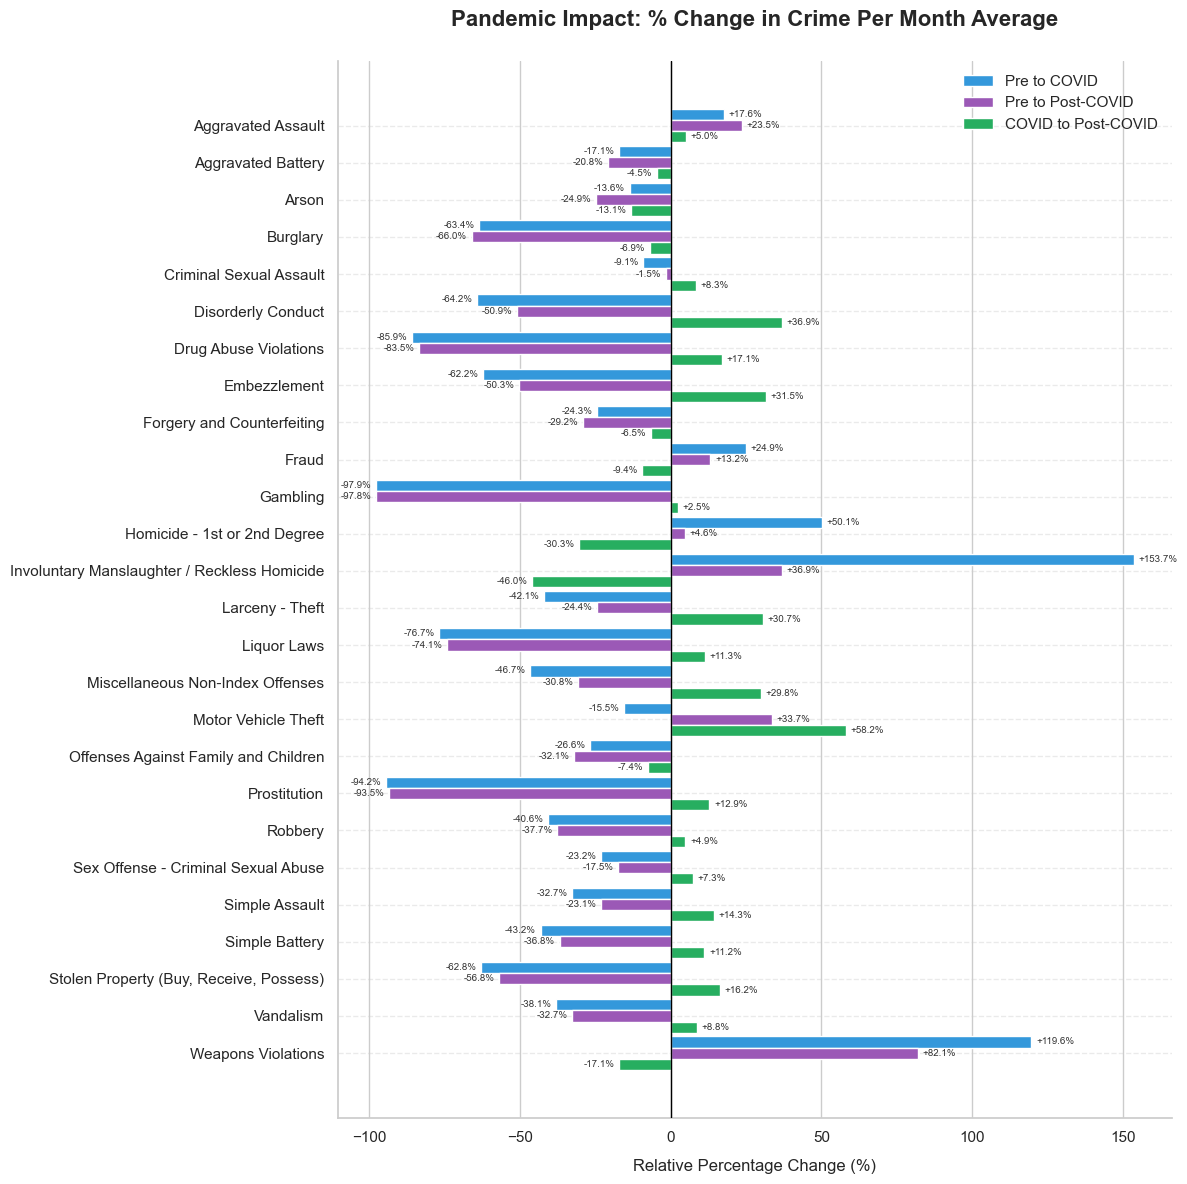

In [25]:
# Set ascending=False so that the first letter (A) appears at the top of the horizontal chart
df_wide = df_wide.sort_values(by='fbi_code_desc', ascending=False)
# plot variables
labels = df_wide['fbi_code_desc']
y = np.arange(len(labels))  # Label locations
height = 0.30  # Width of the bars

# Plot size
fig, ax = plt.subplots(figsize=(12, 12))

# Create grouped bars
bars_pre_covid  = ax.barh(y + height, df_wide[(pct_change_impact, 'pre_to_covid')],  height, label='Pre to COVID',          color='#3498db')
bars_pre_post   = ax.barh(y,          df_wide[(pct_change_impact, 'pre_to_post')],   height, label='Pre to Post-COVID',     color='#9b59b6')
bars_covid_post = ax.barh(y - height, df_wide[(pct_change_impact, 'covid_to_post')], height, label='COVID to Post-COVID',   color='#27ae60')

# --- Bar Labels ---
# Padding (in data units) between bar tip and label
PAD = 1.5

def add_bar_labels(ax, bars, fontsize=7):
    for bar in bars:
        value = bar.get_width()
        x_pos = value + PAD if value >= 0 else value - PAD
        ha    = 'left'       if value >= 0 else 'right'
        ax.text(
            x_pos,
            bar.get_y() + bar.get_height() / 2,
            f"{value:+.1f}%",
            va='center',
            ha=ha,
            fontsize=fontsize,
            color='#333333'
        )

add_bar_labels(ax, bars_pre_covid)
add_bar_labels(ax, bars_pre_post)
add_bar_labels(ax, bars_covid_post)

# Aesthetics
ax.axvline(0, color='black', linewidth=1.0, zorder=3)
ax.set_title('Pandemic Impact: % Change in Crime Per Month Average', fontsize=16, pad=25, fontweight='bold')
ax.set_xlabel('Relative Percentage Change (%)', fontsize=12, labelpad=10)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.legend(frameon=False, loc='upper right')

# Add grid for readability
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Remove chart junk
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()

# Save the figure with high resolution and tight cropping
plt.savefig("../Image/impact_of_covid.png", dpi=600, bbox_inches='tight')
plt.show()

### Dunn's Pairwise Post-Hoc

In [26]:
# Pairwise post-hoc: which era pairs differ?
dunn_results = dunn_posthoc.run_dunn_posthoc(
    data            = multi_counts_df,
    time_col        = 'year_month',
    kruskal_results = monthly_results,
    alpha           = 0.05
)

# Pattern summary
still_shifting = dunn_results[
    (dunn_results['pair'] == 'covid vs post_covid') &  # ← double spaces
    (dunn_results['significant'] == True)
]['crime'].tolist()

print("=== Still Shifting (covid -> post) ===")
print(still_shifting)

print("\n=== Full Recovery (pre ≈ post) ===")
recovered = dunn_results[
    (dunn_results['pair'] == 'pre_covid vs post_covid') &  # ← double spaces
    (dunn_results['significant'] == False)
]['crime'].tolist()
print(recovered)

print("\n=== Inconclusive (KW significant, no significant pairs) ===")
inconclusive = (
    dunn_results
    .groupby('crime')['significant']
    .any()
)
print(inconclusive[inconclusive == False].index.tolist())

=== Still Shifting (covid -> post) ===
[]

=== Full Recovery (pre ≈ post) ===
[]

=== Inconclusive (KW significant, no significant pairs) ===
['Embezzlement']


## Key Findings: Pandemic Impact on Crime Patterns

The dataset covers 26 crime categories across pre-COVID (2001–2020), COVID (2020–2022), and post-COVID (2023–2025) periods, revealing clear and durable level shifts driven by the pandemic.

### Suppressed Crimes (Opportunity & Socially Driven)
Crimes tied to public activity collapsed during COVID:
* Gambling: −97.8% | Prostitution: −93.5% | Drug Abuse: −85.9% (Pre -> COVID)
* Burglary: −63.4% | Robbery: −40.6% | Larceny/Theft: −42.1% (Pre -> COVID)

### Accelerated Crimes
* **Weapons Violations:** spiked +119.6% during COVID, still +81.2% above pre-COVID
* **Motor Vehicle Theft:** +32.8% above pre-COVID, still rising COVID -> post
* **Aggravated Assault:** +22.9% above pre-COVID baseline

### Homicide - A Complete Cycle
Homicide rose +50.1% during COVID (r=+0.667, large) but fully recovered post-COVID - the **only violent crime** to return to its pre-COVID baseline (pre vs post: p=0.814, r=+0.081, negligible).

### Pairwise Analysis: Dunn's Post-Hoc Results
Dunn's post hoc test was run on all 24 significant crimes to identify which pairs of eras drive the differences.

**Crime Trajectories:**

| Trajectory | Count | Crimes |
|---|---|---|
| New permanent baseline | 17 | Shifted from pre-COVID and stabilized |
| Still actively shifting (COVID -> post) | 4 | Motor Vehicle Theft $\uparrow$, Simple Assault $\uparrow$, Misc Non-Index $\uparrow$, Homicide $\downarrow$ |
| Full recovery to pre-COVID | 1 | Homicide (unique - completes full cycle) |
| Inconclusive | 1 | Embezzlement - KW significant but no significant pairs |

**Embezzlement caveat:** Despite a significant Kruskal-Wallis result ($\epsilon=0.021$, small), no individual pairwise comparison survived after 
correction. This result is treated as inconclusive - the omnibus 
test likely detected noise rather than a real structural shift.

**Power warning:** Several `covid vs post_covid` pairs showed large rank-biserial correlations but did not reach significance - most notably Disorderly Conduct (r=+0.697) and Larceny–Theft (r=+0.683). With only 34 COVID months, these comparisons are underpowered. Absence of significance here should not be interpreted as absence of effect.

In [27]:
# Top 3 crimes that increased pre to post
print("=== Largest Increases (Pre -> Post COVID) ===")
print(df_wide.nlargest(3, ('pct_change_impact', 'pre_to_post'))
             [[('fbi_code_desc', ''), ('pct_change_impact', 'pre_to_post')]]
             .to_string(index=False))

print("\n=== Largest Decreases (Pre -> Post COVID) ===")
print(df_wide.nsmallest(3, ('pct_change_impact', 'pre_to_post'))
             [[('fbi_code_desc', ''), ('pct_change_impact', 'pre_to_post')]]
             .to_string(index=False))

print("\n=== Biggest COVID Spike (Pre -> COVID) ===")
print(df_wide.nlargest(3, ('pct_change_impact', 'pre_to_covid'))
             [[('fbi_code_desc', ''), ('pct_change_impact', 'pre_to_covid')]]
             .to_string(index=False))

=== Largest Increases (Pre -> Post COVID) ===
                               fbi_code_desc pct_change_impact
                                                   pre_to_post
                          Weapons Violations         82.054750
Involuntary Manslaughter / Reckless Homicide         36.904762
                         Motor Vehicle Theft         33.707527

=== Largest Decreases (Pre -> Post COVID) ===
        fbi_code_desc pct_change_impact
                            pre_to_post
             Gambling        -97.807608
         Prostitution        -93.487324
Drug Abuse Violations        -83.505443

=== Biggest COVID Spike (Pre -> COVID) ===
                               fbi_code_desc pct_change_impact
                                                  pre_to_covid
Involuntary Manslaughter / Reckless Homicide        153.676471
                          Weapons Violations        119.596609
                Homicide - 1st or 2nd Degree         50.116648


## Weekly Crime Trends Across Eras

Time series of weekly crime counts per crime type, colored by era. Each panel uses independent x and y axes to highlight within-crime patterns rather than cross-crime magnitude.

> **Note:** Pre-COVID spans $\approx 998$ weeks vs $\approx 143$ (COVID) and $\approx 125$ (Post-COVID). Interpret trend shape and direction - not line length across eras.

In [28]:
# Group by the level name and sum up the sizes
week_counts = (
    multi_counts.groupby(level=['fbi_code_desc', 'Indexed', 'year_week', 'era'])
    .sum()
    .reset_index(name='count')
    .astype({'count': 'int64[pyarrow]'})
             )
# display
print(week_counts.isna().any())
week_counts.sort_values(['fbi_code_desc', 'year_week'])
week_counts.head()

fbi_code_desc    False
Indexed          False
year_week        False
era              False
count            False
dtype: bool


,fbi_code_desc,Indexed,year_week,era,count
0,Aggravated Assault,I,2001-01,pre_covid,133
1,Aggravated Assault,I,2001-02,pre_covid,128
2,Aggravated Assault,I,2001-03,pre_covid,112
3,Aggravated Assault,I,2001-04,pre_covid,119
4,Aggravated Assault,I,2001-05,pre_covid,127


## Statistical Note - Sample Size Imbalance

Pre-COVID contributes 1,000 weekly observations vs  149 (COVID) and 157 (post-COVID). This imbalance inflates the number of pre-COVID outlier dots visible in the boxplots - this reflects a larger sample size, not greater crime volatility.

The Kruskal-Wallis H-statistic is computed on ranks and handles this imbalance without bias. However, effect sizes for the smaller COVID and post-COVID eras should be interpreted with caution, as estimates are less stable given fewer observations.

In [29]:
# Convert to Plot-friendly format
convert = week_counts.assign(
    year_week=lambda d: pd.to_datetime(d["year_week"] + "-1", format="%G-%V-%u"),
    count=lambda d: d["count"].astype("float64"),
    era=lambda d: d["era"].astype("category"),
    fbi_code_desc=lambda d: d["fbi_code_desc"].astype("string")
)

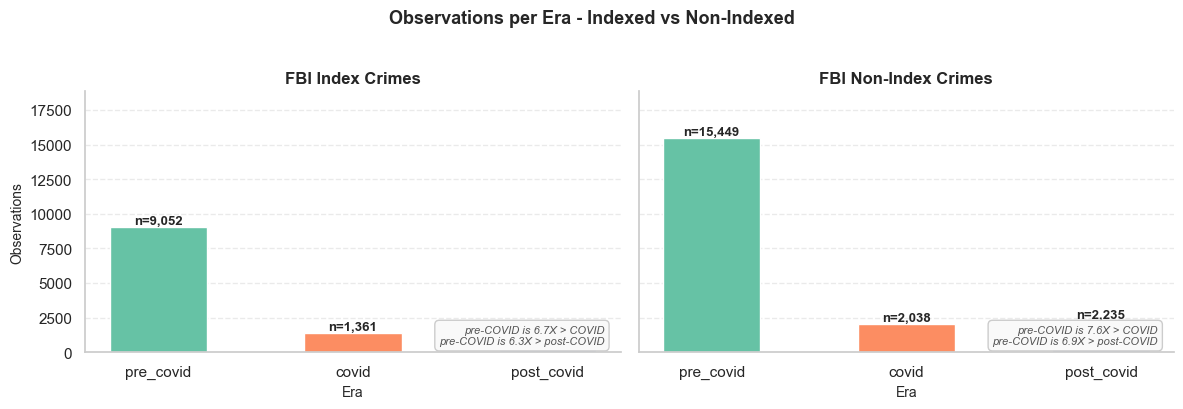

In [30]:
# per era X Indexed - directly matches the two boxplot filters
era_index_counts = (
    convert
    .groupby(['era', 'Indexed'], observed=True)
    .size()
    .reset_index(name='observations')  # ← 'observations' not 'weeks'
)

# Enforce era order
era_order = ['pre_covid', 'covid', 'post_covid']
era_index_counts['era'] = pd.Categorical(
    era_index_counts['era'],
    categories=era_order,
    ordered=True
)
era_index_counts = era_index_counts.sort_values(['Indexed', 'era'])

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

palette   = sns.color_palette('Set2', n_colors=3)
subtitles = {'I': 'FBI Index Crimes', 'N': 'FBI Non-Index Crimes'}

for ax, indexed_val in zip(axes, ['I', 'N']):
    subset = era_index_counts[era_index_counts['Indexed'] == indexed_val]

    bars = ax.bar(
        subset['era'],
        subset['observations'],          # ← 'observations'
        color=palette,
        edgecolor='white',
        width=0.5
    )

    # Bar labels
    for bar, val in zip(bars, subset['observations']):  # ← 'observations'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f'n={val:,}',
            ha='center', va='bottom',
            fontsize=9.5, fontweight='bold'
        )

    # Ratio annotation
    vals = subset.set_index('era')['observations']      # ← 'observations'
    pre  = vals.get('pre_covid', 1)
    cov  = vals.get('covid', 1)
    post = vals.get('post_covid', 1)

    ax.text(
        0.97, 0.105,
        f'pre-COVID is {pre/cov:.1f}X > COVID\n'
        f'pre-COVID is {pre/post:.1f}X > post-COVID',
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=8, style='italic', color='#555555',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='#f9f9f9', edgecolor='#cccccc')
    )

    ax.set_title(subtitles[indexed_val], fontsize=12, weight='bold')
    ax.set_xlabel('Era', fontsize=10)
    ax.set_ylim(0, era_index_counts['observations'].max() * 1.22)  # ← 'observations'

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.grid(axis='x')

axes[0].set_ylabel('Observations', fontsize=10)   # ← updated label
axes[1].set_ylabel('')

fig.suptitle(
    'Observations per Era - Indexed vs Non-Indexed',
    fontsize=13, weight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('../Image/boxplot_index_nonindex_size.png', dpi=600, bbox_inches='tight')
plt.show()

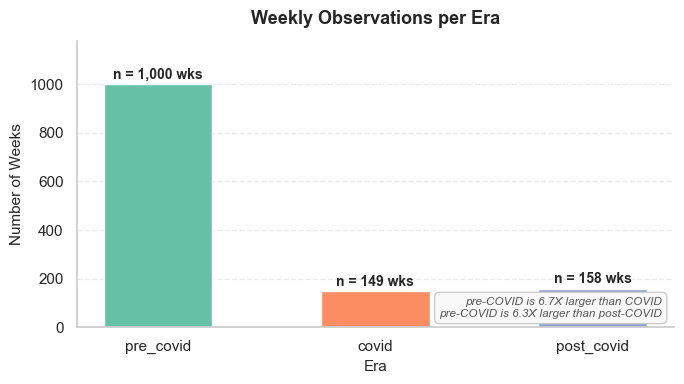

In [31]:
# weekly observations per era
era_counts = (
    convert.groupby('era', observed=True)['year_week']
    .nunique()
    .reset_index(name='weeks')
)

# Enforce order
era_counts['era'] = pd.Categorical(
    era_counts['era'],
    categories=['pre_covid', 'covid', 'post_covid'],
    ordered=True
)
era_counts = era_counts.sort_values('era')

# Plot
fig, ax = plt.subplots(figsize=(7, 4))

palette = sns.color_palette('Set2', n_colors=3)

bars = ax.bar(
    era_counts['era'],
    era_counts['weeks'],
    color=palette,
    edgecolor='white',
    width=0.5
)

# Bar labels - exact counts
for bar, val in zip(bars, era_counts['weeks']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'n = {val:,} wks',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# Ratio annotation
pre = era_counts.loc[era_counts['era'] == 'pre_covid', 'weeks'].values[0]
covid = era_counts.loc[era_counts['era'] == 'covid', 'weeks'].values[0]
post = era_counts.loc[era_counts['era'] == 'post_covid', 'weeks'].values[0]

ax.text(
    0.98, 0.105,
    f'pre-COVID is {pre/covid:.1f}X larger than COVID\n'
    f'pre-COVID is {pre/post:.1f}X larger than post-COVID',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=8.5, style='italic', color='#555555',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#f9f9f9', edgecolor='#cccccc')
)

# Aesthetics
ax.set_title(
    'Weekly Observations per Era',
    fontsize=13, weight='bold', pad=12
)
ax.set_xlabel('Era', fontsize=11)
ax.set_ylabel('Number of Weeks', fontsize=11)
ax.set_ylim(0, era_counts['weeks'].max() * 1.18)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x')

plt.tight_layout()
plt.savefig('../Image/weekly_size_imbalance.png', dpi=600, bbox_inches='tight')
plt.show()

## Distribution Analysis: Indexed vs Non-Indexed Crimes

Box plots show the full distribution of weekly counts (median, IQR, outliers) split by FBI Index classification and era.

**FBI Index Crimes** are the most serious offenses tracked nationally: murder, rape, robbery, aggravated assault, burglary, larceny, motor vehicle theft, and arson.

**Sample size caveat:**

| Era        | Weekly Observations  |
|------------|----------------------|
| Pre-COVID  |  1,000 weeks         |
| COVID      |  149 weeks           |
| Post-COVID |  157 weeks           |

Pre-COVID distributions will show more outlier points - this reflects sample size, not higher crime volatility. Focus on **median shifts and IQR width** across eras, not outlier density.

In [32]:
# Distinct Crime Type Values
print(list(multi_counts.index.get_level_values('fbi_code_desc').unique()))

['Aggravated Assault', 'Aggravated Battery', 'Arson', 'Burglary', 'Criminal Sexual Assault', 'Disorderly Conduct', 'Drug Abuse Violations', 'Embezzlement', 'Forgery and Counterfeiting', 'Fraud', 'Gambling', 'Homicide - 1st or 2nd Degree', 'Involuntary Manslaughter / Reckless Homicide', 'Larceny - Theft', 'Liquor Laws', 'Miscellaneous Non-Index Offenses', 'Motor Vehicle Theft', 'Offenses Against Family and Children', 'Prostitution', 'Robbery', 'Sex Offense - Criminal Sexual Abuse', 'Simple Assault', 'Simple Battery', 'Stolen Property (Buy, Receive, Possess)', 'Vandalism', 'Weapons Violations']


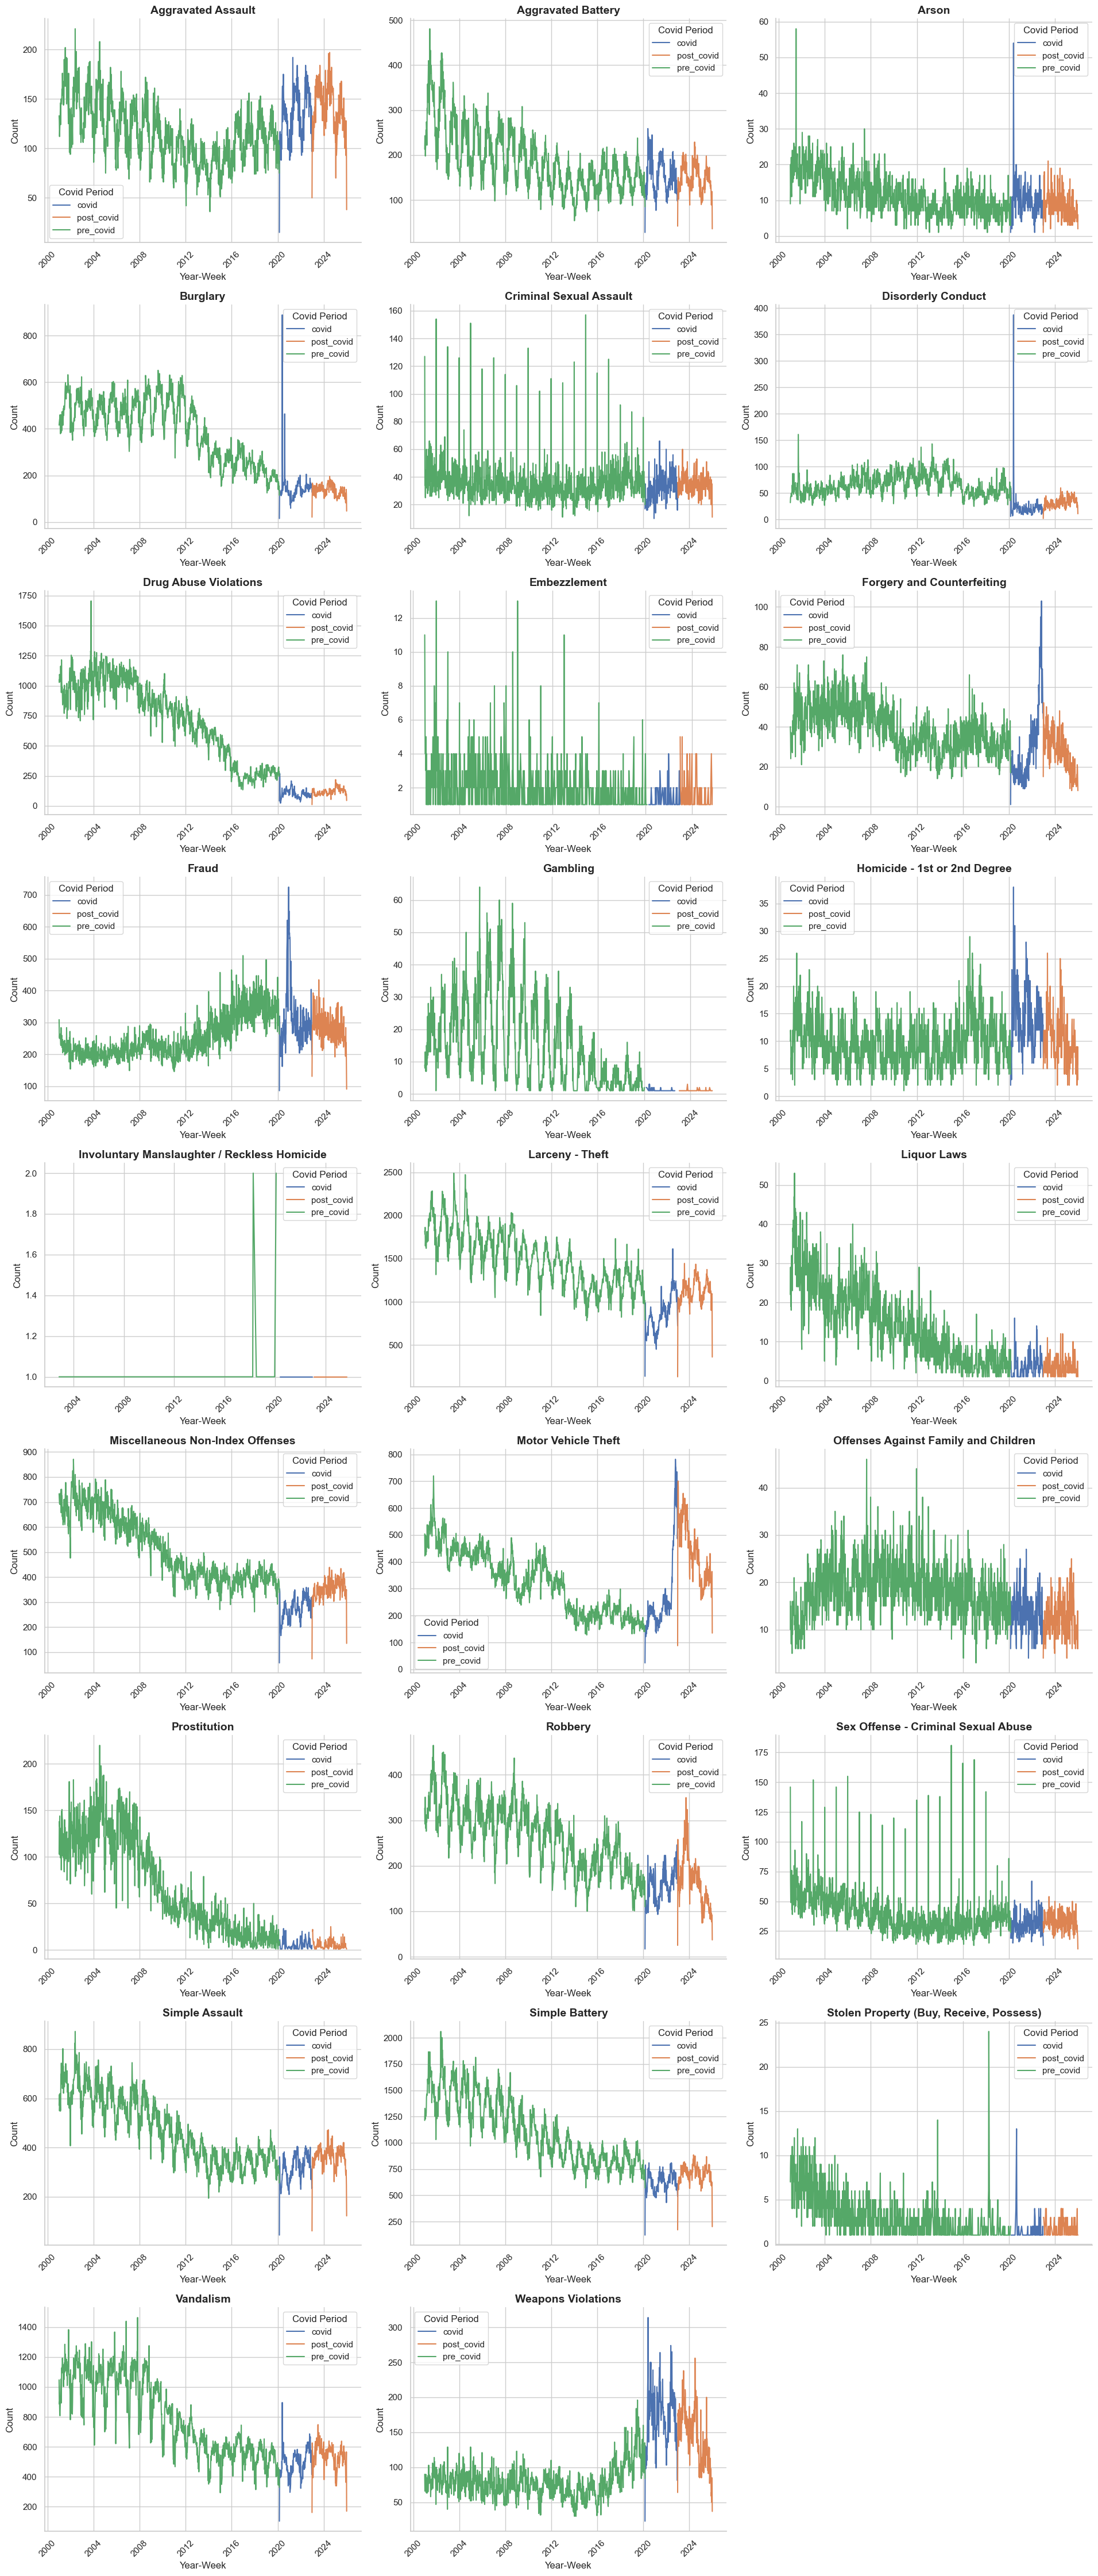

In [33]:
# create a FacetGrid of line plots object
g = sns.relplot(
    data=convert,
    x="year_week",
    y="count",
    hue="era",
    col="fbi_code_desc",
    col_wrap=3,
    kind="line",
    height=5,
    aspect=1.2,
    facet_kws={'sharey': False, 'sharex': False},
    legend=True # Keep this True initially so labels are generated
)

# Extract labels and handles from the global legend before removing
handles, labels = g._legend.legend_handles, [t.get_text() for t in g._legend.get_texts()]

# Remove the default global legend
g._legend.remove()

# Fix titles
g.set_titles(col_template="{col_name}", size=14, weight='bold')

# Iterate through axes to format and add the legend manually
for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=45)   
    # Manually pass the handles and labels we extracted
    ax.legend(handles=handles, labels=labels, title="Covid Period")
    ax.set_xlabel("Year-Week")
    ax.set_ylabel("Count")

plt.tight_layout()
# Save the figure with high resolution and tight cropping
plt.savefig("../Image/time_line_crime_plot.png", bbox_inches='tight')
plt.show()

In [34]:
# Weekly analysis
weekly_results = kruskal_fdr.run_kruskal_fdr(
    data       = convert,
    time_col = 'year_week',
    alpha    = 0.01
)
weekly_results

,crime,statistic,p_value,n,epsilon_squared,p_corrected,significant,effect_size
0,Aggravated Assault,147.46,0.000000,1307,0.112,0.000000,True,medium
1,"Stolen Property (Buy, Receive, Possess)",85.65,0.000000,1019,0.082,0.000000,True,medium
2,Simple Battery,579.05,0.000000,1307,0.443,0.000000,True,large
3,Simple Assault,250.81,0.000000,1307,0.191,0.000000,True,large
4,Sex Offense - Criminal Sexual Abuse,59.39,0.000000,1307,0.044,0.000000,True,small
5,Robbery,414.33,0.000000,1307,0.316,0.000000,True,large
6,Prostitution,433.09,0.000000,1214,0.356,0.000000,True,large
7,Offenses Against Family and Children,225.48,0.000000,1307,0.171,0.000000,True,large
8,Motor Vehicle Theft,135.71,0.000000,1307,0.103,0.000000,True,medium
9,Miscellaneous Non-Index Offenses,588.20,0.000000,1307,0.450,0.000000,True,large


> **Statistical note - sample size imbalance**
> pre-COVID contributes $\approx$998 weekly observations vs. $\approx$143 (COVID) and $\approx$125
> (post-COVID). This imbalance inflates the number of pre-COVID outlier dots
> visible in the boxplot, which reflects a larger sample size, not greater
> crime volatility. The Kruskal-Wallis H-statistic is computed on ranks, so
> it handles this imbalance without bias, but effect sizes for the smaller
> eras should be read cautiously.

In [35]:
def plot_boxstrip(
    data:         pd.DataFrame,
    indexed_val:  str,
    save_path:    str   = "../Image/xxxxxxxxxxxxx_plot.png",
    legend_order: list  = None,
    legend_title: str   = "Period",
    figsize:      tuple = (16, 12)
) -> None:
    """
    Boxplot + Stripplot overlay for Indexed or Non-Indexed crimes.

    Parameters
    ----------
    data         : convert DataFrame
    indexed_val  : 'I' for Indexed, 'N' for Non-Indexed
    save_path    : full save path e.g. '../Image/box_indexed_crime_plot.png'
    legend_order : era order (default: pre_covid, covid, post_covid)
    legend_title : legend header (default: 'Period')
    figsize      : figure size (default: (16, 12))
    """
    # ── Defaults ─────────────────────────────────────────────────────────
    if legend_order is None:
        legend_order = ["pre_covid", "covid", "post_covid"]

    # ── Title - derived from indexed_val, no bug risk ─────────────────────
    index_label = "Indexed" if indexed_val.upper() == 'I' else "Non-Indexed"
    title = f"Distribution of {index_label} Crime Counts: Pre-COVID, COVID & Post-COVID"

    # ── Data filter ───────────────────────────────────────────────────────
    plot_data = data.loc[data['Indexed'] == indexed_val]

    # ── Plot ──────────────────────────────────────────────────────────────
    _, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=plot_data,
        x="fbi_code_desc",
        y="count",
        hue="era",
        hue_order=legend_order,
        palette="Set2",
        flierprops=dict(marker='o', markersize=3, alpha=0.5, linestyle='none'),
        ax=ax
    )

    sns.stripplot(
        data=plot_data,
        x="fbi_code_desc",
        y="count",
        hue="era",
        hue_order=legend_order,
        palette="Set2",
        size=1.8,
        alpha=0.20,
        jitter=True,
        dodge=True,
        legend=False,
        ax=ax
    )

    # ── Labels ────────────────────────────────────────────────────────────
    ax.set_title(title, size=14, weight='bold')
    ax.set_xlabel("Crime Type")
    ax.set_ylabel("Count")
    ax.legend(title=legend_title, frameon=True)
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

## Indexed Plot

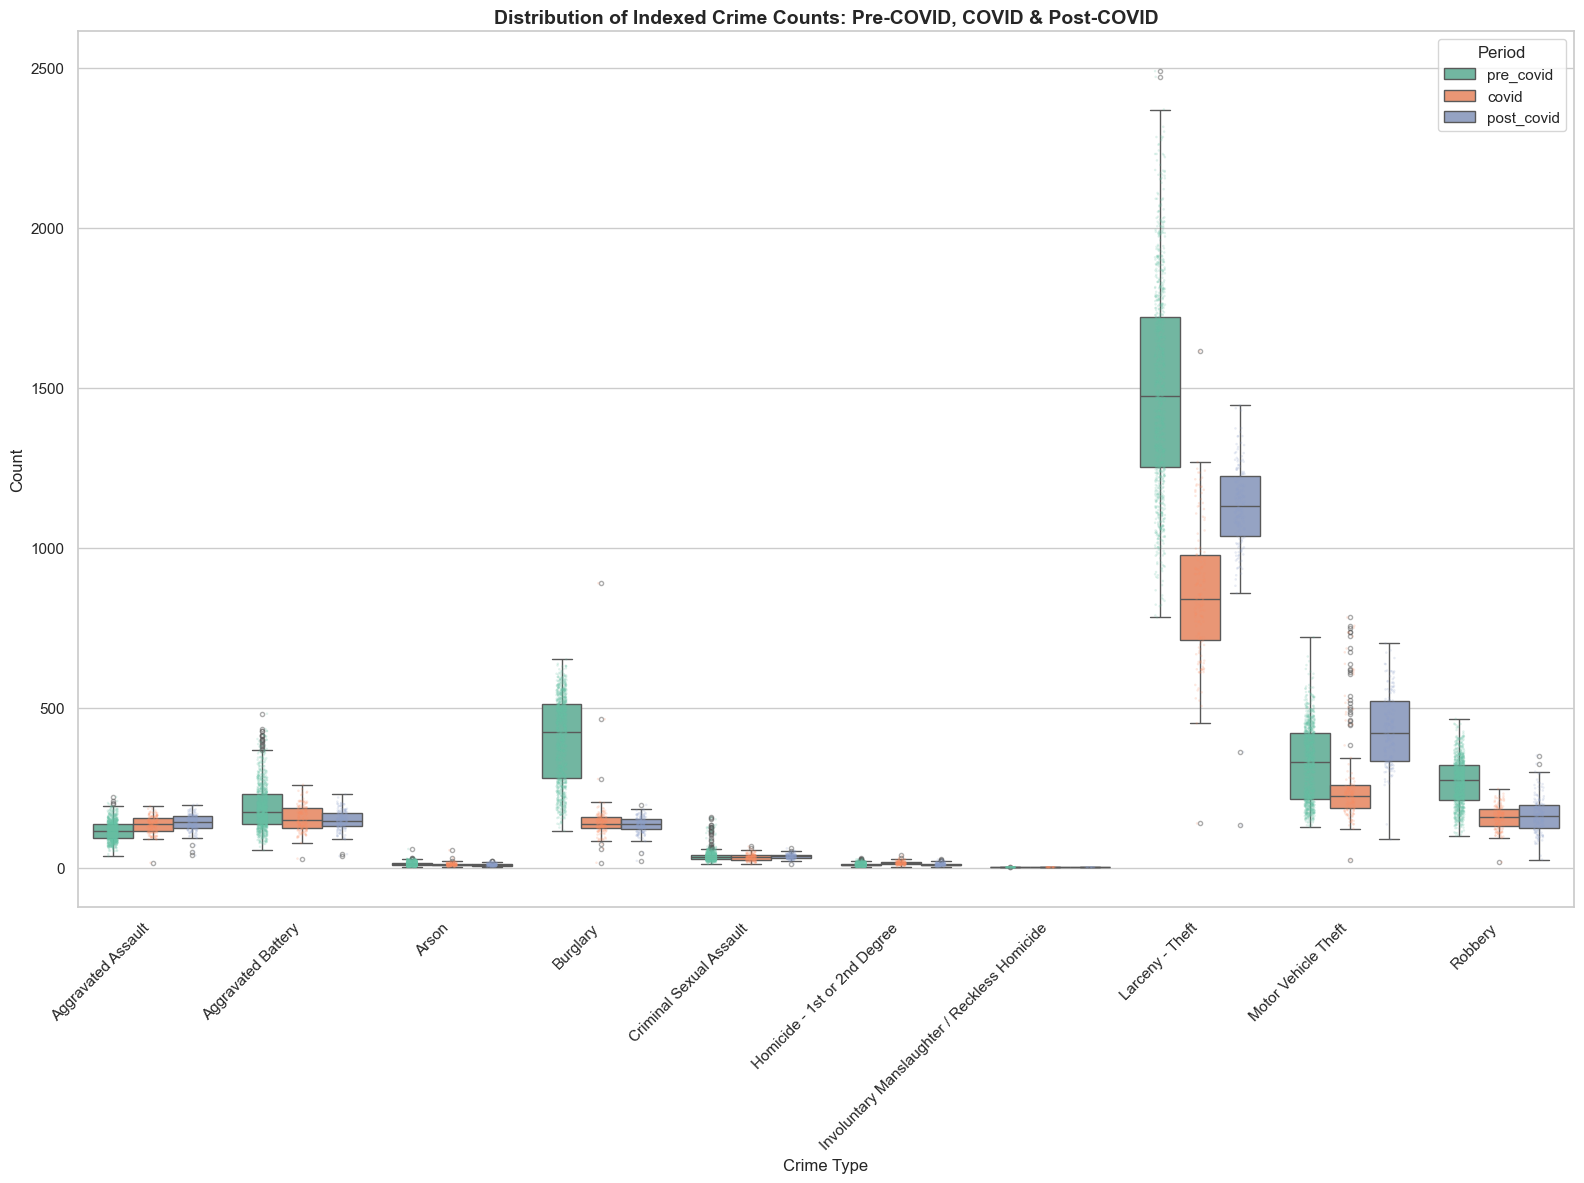

In [36]:
# Indexed
plot_boxstrip(
    data        = convert,
    indexed_val = 'I',
    save_path   = "../Image/box_indexed_crime_plot.png"
)

## Non-Indexed

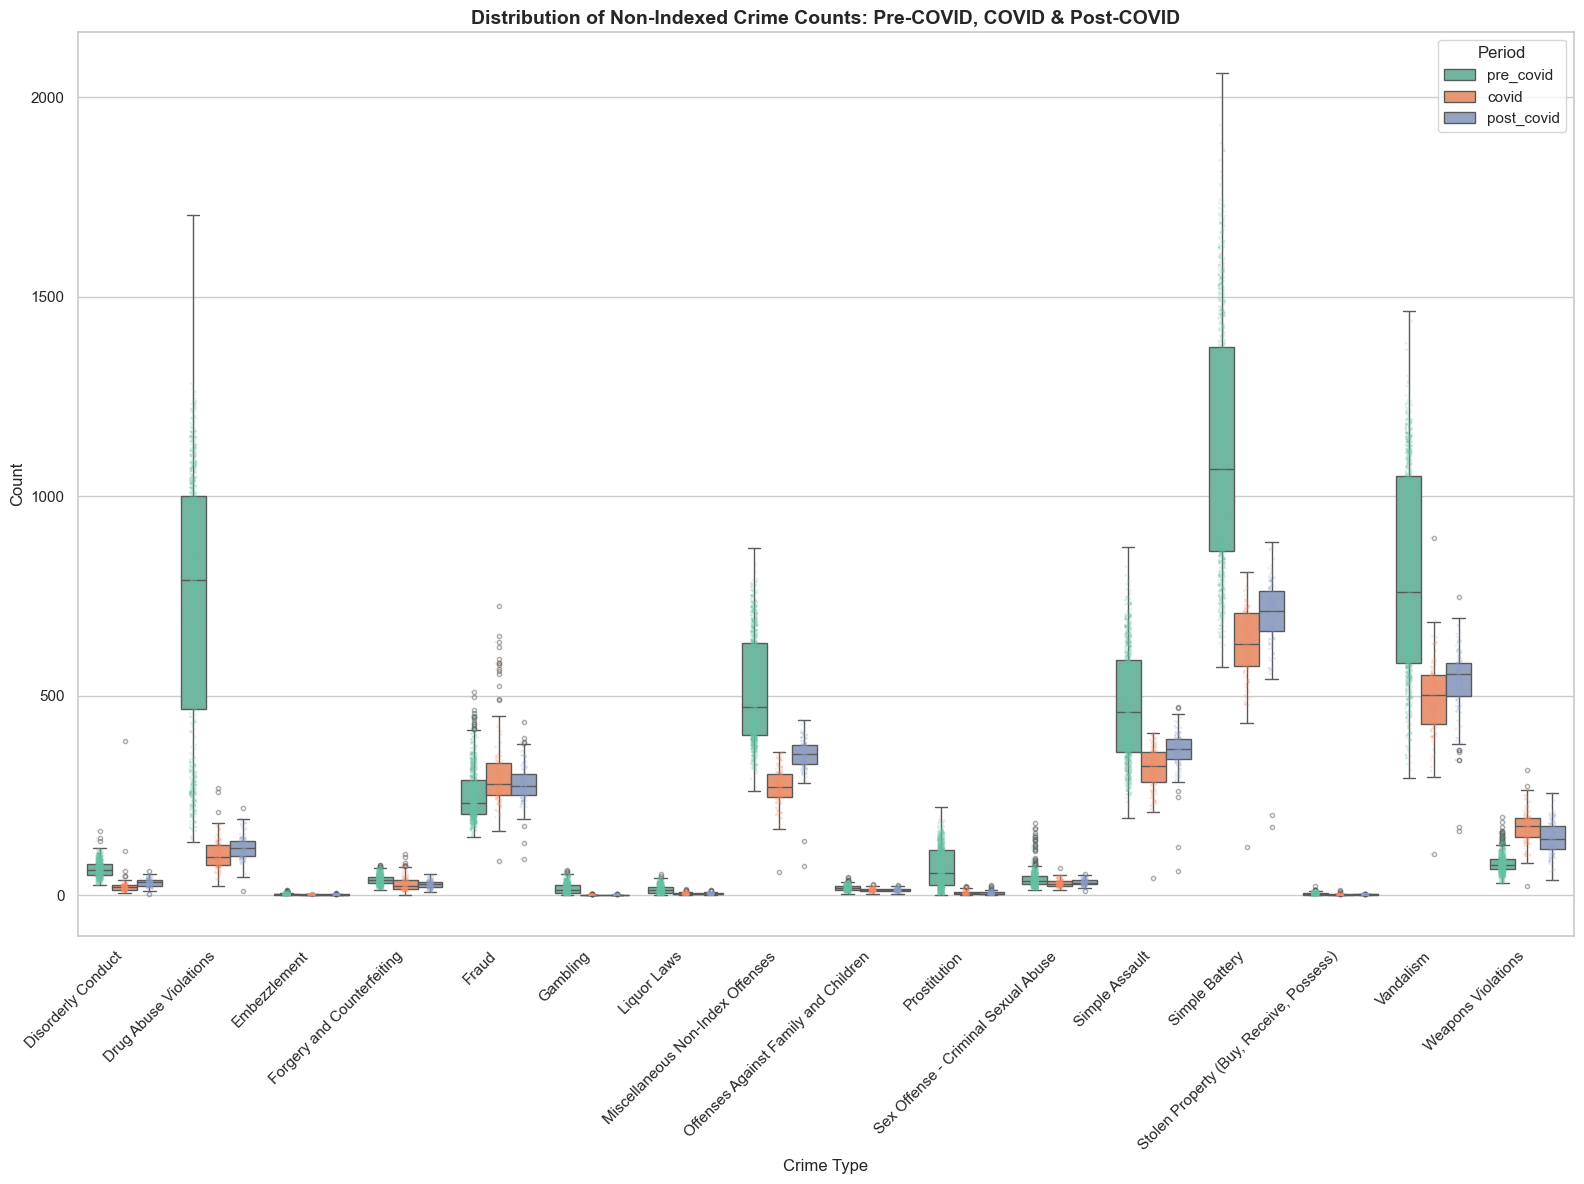

In [37]:
# Non-Indexed
plot_boxstrip(
    data        = convert,
    indexed_val = 'N',
    save_path   = "../Image/box_nonindexed_crime_plot.png"
)

## Limitations

- **Unequal era lengths** crimes/month normalization applied, but does not fully control for seasonal, economic, or policy confounders.
- **Kruskal-Wallis is omnibus** confirms that differences exist across eras, not which era pairs drive them. Dunn's post hoc test was applied to all 24 significant crimes to perform pairwise comparisons.
- **Temporal autocorrelation** monthly crime counts in adjacent periods are not fully independent. Kruskal-Wallis assumes independence; p-values may be slightly optimistic. Results are treated as exploratory.
- **Reported vs actual crime** changes in policing priorities, reporting behavior, and legal reclassification can affect counts independently of true crime rates. The Drug Abuse Violations collapse is a clear example.
- **COVID era is short** 34 months yields less stable estimates than 230 months of pre-COVID data. Several COVID vs. post-COVID comparisons are likely underpowered despite large effect sizes.

---

## Conclusion

24 of 26 crime types changed significantly across eras after Benjamini-Hochberg FDR correction. The pandemic produced two durable level shifts: a collapse in opportunity-driven crimes (gambling −97.8%, prostitution −93.5%, drug abuse −83.6%) and an acceleration of violence-related offenses (weapons violations +81.2%, motor vehicle theft +32.8%, aggravated assault +22.9%).

Dunn's post-hoc testing revealed that 17 of 24 significant crimes have stabilized into a new post-COVID baseline. Four crimes, Motor Vehicle Theft, Simple Assault, Miscellaneous Non-Index Offenses, and Homicide, remain in active transition. Homicide is uniquely notable as the only violent crime to complete a full recovery to pre-COVID levels.Post-COVID data suggest these level shifts appear durable through the post-COVID observation window, though 36 months is insufficient to rule out further change.


## Next Steps

1. **Geographic analysis** *(highest impact)* which community areas drove the Weapons Violations spike? Neighborhood-level variation is masked by city-wide aggregation.
2. **Correlation analysis** - COVID case rates vs weekly crime counts 
   to test whether pandemic severity predicts crime timing.
3. **Forecasting** - SARIMA or Prophet model on post-COVID trajectory 
   for the 4 still-shifting crimes.

## Save using PyArrow

In [38]:
# Save as Arrow
df.to_feather("../Data/crime_data_covid.feather")